Assignment : Image Segmentation & Maskrcnn Practical

Image Segmentation and Maskrcnn


In [ ]:
1. What is image segmentation, and why is it important?


Image segmentation is a computer vision technique that involves dividing an image into multiple meaningful parts or regions. In simple terms, it’s like coloring different parts of an image with different labels so you know which pixels belong to what.

Example: In a photo of a cat on grass, segmentation can separate the cat from the background and the grass.

How it works: It labels each pixel in the image with a class or object ID — e.g., ‘cat’, ‘grass’, ‘sky’.

2. Why is image segmentation important?
✅ a. Precise object localization:
It goes beyond simple object detection (which uses bounding boxes) by providing exact shapes and boundaries. This is critical for tasks where precise location matters, like medical imaging.

✅ b. Enables detailed analysis:
In self-driving cars, road lanes, pedestrians, and other vehicles must be segmented accurately to understand the driving scene.

✅ c. Foundational for advanced tasks:
It’s used in:

Medical imaging: Identifying tumors, organs, or tissues in MRI or CT scans.

Agriculture: Detecting plant diseases on leaves.

Satellite imagery: Mapping land use, deforestation, or urban areas.

AR/VR: Separating foreground (people) from background for virtual environments.

✅ d. Enhances automation:
Segmentation enables robots or AI systems to interact intelligently with specific parts of an image, which is important for industrial inspection, sorting, or quality control.

🔑 In short:
Image segmentation helps machines “see” at the pixel level, enabling detailed understanding and precise actions that would not be possible with just whole-image or bounding box predictions.

In [ ]:
2. Explain the difference between image classification, object detection, and image segmentation?

📷 1️⃣ Image Classification
What it does:
Assigns a single label to an entire image.
→ “What is in this image?”

Example:
An image is labeled as “cat” or “dog”. No location or shape info.

Output:
One class per image.

🟦 2️⃣ Object Detection
What it does:
Finds where objects are in an image and what they are.
→ “What objects are there and where are they?”

Example:
Detects a cat and a dog in the same image and draws bounding boxes around each.

Output:
Bounding boxes + class labels for each detected object.

🗺️ 3️⃣ Image Segmentation
What it does:
Classifies every pixel in the image into a class, producing much finer details than bounding boxes.
→ “Which pixels belong to which object?”

Types:

Semantic segmentation:
Classifies pixels by class only. All cats are the same label.

Instance segmentation:
Separates individual instances of objects too. Two cats will have different IDs.

Example:
Highlights the precise shape of the cat and dog, pixel by pixel.

Output:
A mask for each class or instance.

✅ Key Differences in a Nutshell
Aspect	Image Classification	Object Detection	Image Segmentation
Task	What’s in the image?	What and where are objects?	Which pixels belong where?
Output	One label per image	Bounding boxes + labels	Pixel-wise masks
Granularity	Coarse	Medium (rough shape)	Fine (exact shape)

Visual Example:

Imagine an image of two cats on a sofa:

🏷️ Classification: “Cat”

🔲 Detection: Boxes around each cat, labeled “cat”

🎨 Segmentation: Every pixel of each cat accurately outlined and separated from sofa




In [ ]:
3. What is Mask R-CNN, and how is it different from traditional object detection models?

✅ 1. What is Mask R-CNN?
Mask R-CNN stands for Mask Region-based Convolutional Neural Network.
It’s an advanced deep learning model that extends Faster R-CNN (a popular object detection model) to do instance segmentation — which means it can:

Detect objects: Where are they?

Classify objects: What are they?

Segment objects: Which pixels belong to each object?

So you get bounding boxes, class labels, and pixel-accurate masks for each detected instance.

✅ 2. How does Mask R-CNN work?
Base: It uses Faster R-CNN, which has:

A backbone CNN (like ResNet) to extract feature maps.

A Region Proposal Network (RPN) to find regions likely to contain objects.

A RoI (Region of Interest) Pooling layer to crop those regions for classification and bounding box regression.

Addition: Mask R-CNN adds a branch to predict a binary mask for each RoI, so you get the exact shape, not just a box.

Key innovation: Instead of RoI Pooling, it uses RoI Align, which fixes misalignments caused by quantization — this improves mask quality a lot!

✅ 3. How is Mask R-CNN different from traditional object detection models?
Aspect	Traditional Object Detection (e.g., Faster R-CNN, YOLO, SSD)	Mask R-CNN
Output	Bounding boxes + class labels	Bounding boxes + class labels + pixel masks
Shape precision	Rough outline (box)	Exact object shape (mask)
Use case	Good for counting objects, tracking	Needed when you care about object boundaries — e.g., medical imaging, autonomous driving
RoI operation	RoI Pooling	RoI Align (more accurate for masks)

✅ 4. Why is this important?
📌 Traditional detectors can’t separate overlapping objects precisely — they overlap boxes.
📌 Mask R-CNN can separate instances even if they touch, because each mask is pixel-accurate.
📌 It works well for complex scenes, detailed editing, AR, medical analysis, etc.

🗂️ In short
Mask R-CNN = Faster R-CNN + pixel masks + RoI Align

It’s one of the go-to models for instance segmentation, giving you what, where, and which pixels all in one shot!




In [ ]:
4. What role does the "RoIAlign" layer play in Mask R-CNN?


RoIAlign (Region of Interest Align) is a layer used in Mask R-CNN to extract fixed-size feature maps for each Region of Interest (RoI) — but it does so without misalignment.

✅ Why was it needed?
Before RoIAlign, Faster R-CNN used RoI Pooling, which does:

Takes the bounding box proposal (RoI)

Divides it into a grid (like 7×7)

Quantizes coordinates (rounds them to integers)

Applies max pooling in each grid cell

Problem:
The rounding step introduces misalignment between the original RoI in the input image and the features extracted. This is acceptable for detection (where bounding boxes are coarse), but it causes blurry, inaccurate masks when doing pixel-wise segmentation.

✅ How does RoIAlign fix this?
RoIAlign:

Removes quantization: It doesn’t round coordinates.

Uses bilinear interpolation to compute the exact values at sampled points inside each bin.

Produces a more precise, smoothly aligned feature map for each RoI.

So your extracted feature map matches the input region more accurately, resulting in:

Sharper, more precise masks.

Better boundaries.

Better overall performance for segmentation.

✅ Key difference
Layer	RoIPool	RoIAlign
Rounding	Rounds coordinates	Keeps floating points
Sampling	Rigid pooling	Bilinear interpolation
Output	Roughly aligned	Accurately aligned
Impact	Good for detection	Critical for masks

✅ In short
RoIAlign ensures that the region extracted from the feature map exactly matches the corresponding region in the input image.

In [ ]:
5. What are semantic, instance, and panoptic segmentation?

1. Semantic Segmentation
What it does:
Classifies every pixel into a category or class.
It answers: “What class does this pixel belong to?”

Key point:
It does not distinguish between different instances of the same class.

Example:
In an image with 3 cars → all pixels belonging to cars are labeled “car” — no separation between the 3 cars.

Use cases:
Road scene understanding, land cover classification, medical tissue segmentation.

✅ 2. Instance Segmentation
What it does:
Classifies every pixel and distinguishes between individual instances of objects within each class.

Key point:
You get “which object does this pixel belong to?” and “which instance of the object?”

Example:
In an image with 3 cars → each car gets its own mask: Car 1, Car 2, Car 3.

Use cases:
Self-driving cars, AR, robotics — anywhere overlapping objects must be separated.

✅ 3. Panoptic Segmentation
What it does:
Combines semantic and instance segmentation in one unified task.

Key point:

Stuff classes: Like sky, road, grass — amorphous regions. You only care about the class.

Thing classes: Countable objects like people, cars, animals — you care about individual instances.

So, panoptic segmentation assigns every pixel both a class label and an instance ID (if applicable).

Example:
In a street scene:

Road, sky → labeled as “stuff” (no instance IDs)

Cars, pedestrians → labeled as “things” (with instance IDs)

Use cases:
Complex scene understanding — e.g., autonomous driving, mapping, AR, large-scale image parsing.

✅ Summary Table
Aspect	Semantic Segmentation	Instance Segmentation	Panoptic Segmentation
Goal	Label each pixel with a class	Label each pixel with class & instance ID	Both semantic & instance labels
Stuff classes	Yes	No	Yes
Thing classes	No distinction	Yes	Yes
Example	All cars = “car”	Each car separate	Stuff + things together

📌 In short
Semantic: What is where?

Instance: What is where, for each object?

Panoptic: What is where, for both stuff and things?




In [ ]:
6. Describe the role of bounding boxes and masks in image segmentation models?


Bounding Boxes: What are they for?
A bounding box is a rectangle that encloses an object in an image.

In object detection models (like Faster R-CNN, YOLO, SSD), bounding boxes are the primary output.
👉 They say “where is the object roughly?”

They’re fast, simple, and good for counting or tracking objects — but they don’t provide pixel-level precision.

✅ Masks: What are they for?
A mask is a pixel-level map that specifies exactly which pixels belong to an object.

In image segmentation, especially instance segmentation (like Mask R-CNN), masks give you the exact shape and boundaries of each object.
👉 They say “which pixels are part of the object?”

Masks enable fine-grained tasks like:

Removing backgrounds

Measuring areas

Analyzing object shapes

Working with overlapping objects

✅ How do they work together in segmentation models?
In models like Mask R-CNN, the process is:

Bounding box:
The Region Proposal Network (RPN) first generates bounding boxes for potential objects.
These boxes roughly localize objects and crop regions of interest (RoIs).

Masks:
For each bounding box, a mask branch predicts a binary mask that refines the shape within that box — giving you pixel-level accuracy.

So:

The box gives you where to look.

The mask gives you which pixels matter inside that region.

✅ When is this distinction important?
Aspect	Bounding Box	Mask
Precision	Rough	Precise
Shape info	Coarse rectangle	Exact silhouette
Use case	Counting, tracking, object presence	Detailed shape, area, editing, AR
Example	“There’s a cat here”	“These exact pixels are the cat”

✅ Key takeaway
🔲 Bounding boxes are like saying “an object is in this region.”
🎭 Masks say “these exact pixels belong to the object.”

Together, they make segmentation models powerful for tasks where fine-grained understanding of shape and boundaries is crucial.

In [ ]:
7. What is the purpose of data annotation in image segmentation?

In image segmentation, data annotation means labeling each pixel in an image with its correct class or instance ID.
Unlike simple classification (one label per image) or detection (bounding boxes), segmentation requires pixel-level labels, which is much more detailed.

🟢 Semantic segmentation: Each pixel gets a class label (e.g., “car”, “road”, “tree”).

🟢 Instance segmentation: Each pixel gets a class label and an instance ID (e.g., Car 1, Car 2).

🟢 Panoptic segmentation: Combines both — “stuff” regions + “thing” instances.

✅ Why is annotation so important?
1️⃣ Supervised training needs ground truth

Deep learning models learn by comparing their predictions to the annotated ground truth.

Without pixel-level labels, the model can’t learn which pixels belong where.

2️⃣ Helps the model generalize

High-quality, diverse annotations help the model handle different shapes, occlusions, lighting, and overlapping objects.

3️⃣ Accuracy depends on annotation quality

Errors or sloppy masks in annotations lead to inaccurate models.

Especially critical in fields like medical imaging or autonomous driving where precision is vital.

4️⃣ Enables model evaluation

Annotations serve as the gold standard for computing metrics like IoU (Intersection over Union), Dice coefficient, or pixel accuracy.

✅ What does it involve?
Manual work:
Annotators often use tools to draw outlines or paint masks.
Example tools: LabelMe, CVAT, Supervisely, VGG Image Annotator (VIA).

Time-consuming:
Pixel-wise annotation is tedious, especially for large or complex datasets.
High-quality datasets (like COCO, Cityscapes, ADE20K) are valuable because they come with detailed masks.

✅ Key takeaway
🏷️ Purpose:
Provide high-quality, pixel-level “ground truth” so that image segmentation models can learn to predict what each pixel represents.

No annotated masks → no way for the model to learn boundaries and shapes → poor segmentation results.




In [ ]:
8. How does Detectron2 simplify model training for object detection and segmentation tasks?

. Modular and Extensible Architecture
Detectron2 is built on PyTorch and follows a modular design, allowing researchers and developers to:

Easily plug in custom datasets, models, and layers.

Customize components like data loaders, augmentations, loss functions, and heads (e.g., RPN, ROI heads) without rewriting core code.

2. Built-in Support for State-of-the-Art Models
Detectron2 provides implementations of modern architectures such as:

Faster R-CNN, Mask R-CNN, RetinaNet, and Cascade R-CNN

With pre-trained weights, making transfer learning and fine-tuning simple.

3. Easy Dataset Integration
It supports COCO format out of the box, and offers easy ways to register custom datasets with only a few lines of code:

python
Copy
Edit
from detectron2.data.datasets import register_coco_instances
register_coco_instances("my_dataset", {}, "path/to/annotations.json", "path/to/images")
4. High-Level Configuration System
Detectron2 uses YAML config files and a flexible config system that lets you:

Modify training parameters without touching code.

Override any parameter at runtime with command-line flags or Python.

5. Powerful Training Tools
Built-in training loops with logging, checkpointing, evaluation, and visualization.

Integration with TensorBoard or custom hooks for monitoring and debugging.

Automatic multi-GPU and mixed precision support (via Apex or PyTorch AMP).

6. Strong Community and Documentation
Actively maintained with frequent updates.

Well-documented APIs and tutorials help beginners and researchers alike.

Community support via GitHub, forums, and blogs.

Summary
Detectron2 simplifies model training by providing a flexible, modular, and user-friendly framework that abstracts away the low-level complexity of building object detection and segmentation pipelines. It helps users focus more on experimentation and less on boilerplate code.

In [ ]:
9. Why is transfer learning valuable in training segmentation models?


✅ What is transfer learning?
Transfer learning means you start with a model that’s been pretrained on a large, general dataset (like ImageNet or COCO) and then fine-tune it for your specific task.
In segmentation, this often means:

Using a pretrained backbone (e.g., ResNet, VGG) to extract visual features.

Fine-tuning the rest of the segmentation head for your domain (e.g., medical, satellite).

✅ Why is transfer learning important for segmentation?
1️⃣ Solves data scarcity
Pixel-level annotation is very costly and time-consuming.

Most segmentation datasets are small compared to classification datasets like ImageNet.

Transfer learning lets you leverage knowledge from big datasets → better performance with less labeled data.

2️⃣ Faster convergence
The pretrained model already knows how to detect edges, textures, and shapes.

This means it starts with useful feature maps, so training takes less time than starting from random weights.

3️⃣ Better generalization
A model trained from scratch on a small dataset may overfit.

A pretrained backbone has seen millions of images, so its features are robust and help the model generalize to unseen data.

4️⃣ State-of-the-art performance
Many top-performing segmentation architectures (like U-Net, DeepLab, Mask R-CNN) rely on transfer learning.

Example: U-Net with a pretrained encoder (like ResNet) is much more accurate than training the entire network from scratch.

✅ Example
Aspect	Without Transfer Learning	With Transfer Learning
Data needed	Large dataset needed	Smaller dataset works
Training time	Longer	Faster
Performance	May be poor if data is small	More accurate, robust
Use case	Rarely used	Almost standard practice

✅ Key takeaway
🔑 Transfer learning = using existing knowledge to boost learning on a new task.

In segmentation, it’s especially valuable because:
✔️ Pixel-wise labels are expensive to get
✔️ Models benefit from features learned on big, diverse datasets
✔️ It saves time, cost, and improves performance



In [ ]:
10. How does Mask R-CNN improve upon the Faster R-CNN model architecture?

Mask R-CNN improves upon the Faster R-CNN architecture by adding a branch for predicting segmentation masks, enabling instance segmentation (detecting what and where each object is at the pixel level), not just bounding boxes and class labels.

Here’s a breakdown of the improvements:

🔧 1. Addition of a Mask Prediction Branch
Faster R-CNN outputs:

Class label

Bounding box coordinates

Mask R-CNN adds:

A third branch: a small fully convolutional network (FCN) to predict a binary mask for each detected object.

📌 This allows Mask R-CNN to not just detect "there's a cat here" but to also outline the exact shape of the cat.

🔄 2. RoIAlign Instead of RoIPool
Faster R-CNN uses RoIPool to extract features from regions of interest, which involves quantization and can cause misalignment.

Mask R-CNN replaces it with RoIAlign, which:

Uses bilinear interpolation

Preserves spatial alignment between features and original image

Crucial for pixel-accurate segmentation

🧠 3. Multi-Task Learning
The network is trained to:

Classify objects

Refine bounding boxes

Generate accurate pixel-wise masks

This joint learning improves overall performance, especially in complex scenes.

🔍 Summary Table:
Feature	Faster R-CNN	Mask R-CNN
Object Detection	✅	✅
Bounding Box Regression	✅	✅
Instance Segmentation	❌	✅
RoI Operation	RoIPool	RoIAlign
Output	Class + Box	Class + Box + Mask

✅ In Summary:
Mask R-CNN enhances Faster R-CNN by:

Adding instance-level mask prediction

Using RoIAlign for better localization

Offering a unified framework for detection and segmentation tasks

It makes pixel-perfect object segmentation possible — a major leap forward for applications like autonomous driving, medical imaging, and visual scene understanding.


In [ ]:
11. What is meant by "from bounding box to polygon masks" in image segmentation?


Fantastic — this phrase “from bounding box to polygon masks” is an important idea when you move from object detection to precise image segmentation. Let’s break it down:

✅ What does it mean?
Bounding box:

A rectangle that encloses an object.

Used in object detection.

Gives rough location only — no shape details.

Polygon mask:

A set of connected points outlining the exact shape of an object.

Used in instance segmentation.

Provides pixel-level precision.

So, “from bounding box to polygon masks” means you go beyond just knowing “the object is somewhere inside this box” — you also get its precise outline or contour.

✅ Why is this important?
1️⃣ More accurate representation

A bounding box may contain background pixels.

A polygon mask tells you exactly which pixels belong to the object.

2️⃣ Better for overlapping objects

Bounding boxes may overlap, making it unclear where one object ends and another starts.

Polygon masks can separate instances cleanly.

3️⃣ Enables detailed tasks

Removing backgrounds, AR overlays, medical segmentation, or calculating area and shape features requires masks — not just boxes.

✅ How is this done in practice?
Models like Mask R-CNN:

They first generate Region Proposals → bounding boxes.

Then, for each box, they predict a binary mask (often encoded as a polygon or bitmap) for the precise shape inside that region.

Annotation:

In datasets like COCO, masks are often stored as polygon coordinates — which can be rasterized into pixel masks when needed.

✅ Example
Stage	What you have
🟩 Bounding box	x_min, y_min, x_max, y_max
🔷 Polygon mask	[(x1, y1), (x2, y2), ..., (xn, yn)] points outlining the object

Example:

Bounding box: The cat is in a 100×100 pixel region.

Polygon: The cat’s ears, tail, and body contour are traced so you know its true shape within that region.

✅ Key takeaway
📦 Bounding box = rough “where”
🔷 Polygon mask = precise “what pixels belong to the object?”

“From bounding box to polygon masks” = advancing from coarse detection to fine-grained segmentation.

12. How does data augmentation benefit image segmentation model training?

Data augmentation significantly benefits image segmentation model training by improving the model’s generalization, robustness, and performance. Here's how:

🔄 1. Increases Dataset Size (Artificially)
Augmentation creates new, varied examples from existing images.

Helps combat overfitting, especially when labeled data is limited.

Example: From one labeled image, augmentations like flip, rotation, or crop can create dozens of unique training samples.

🧠 2. Improves Model Generalization
Models learn to recognize features under various conditions (e.g., different orientations, lighting, scales).

Encourages learning invariant features, not just memorizing patterns.

🛡️ 3. Enhances Robustness to Real-World Variations
Trains the model to perform well on images it has never seen before but that share similar characteristics.

Helps the model adapt to:

Camera noise

Occlusions

Different object positions or shapes

🔄 4. Simulates Realistic Conditions
Augmentations like:

Brightness/contrast adjustments

Motion blur or zoom

Elastic deformation (useful for medical or satellite imagery)

Mimic natural variations in real-world data.

🎯 5. Improves Boundary Learning
Random cropping, resizing, and elastic transformations force the model to learn precise object boundaries, which is critical in segmentation tasks.

⚙️ Common Augmentation Techniques in Image Segmentation:
Category	Techniques
Geometric	Flip, rotation, scaling, cropping
Color/Light	Brightness, contrast, hue shift
Noise	Gaussian noise, blur
Spatial	Elastic transform, random erasing

Important: For segmentation, augmentations must be applied identically to both the image and its mask, to preserve pixel-to-pixel alignment.

✅ In Summary:
Data augmentation makes image segmentation models:

More accurate

Less overfit

Better at handling edge cases

And ultimately more reliable for real-world deployment.


In [ ]:
13. Describe the architecture of Mask R-CNN, focusing on the backbone, region proposal network (RPN), and segmentation mask head.

Overview: What is Mask R-CNN?
Mask R-CNN extends Faster R-CNN to do instance segmentation — it detects objects, classifies them, and generates pixel-wise masks for each detected object.

The main parts are:

Backbone

Region Proposal Network (RPN)

Segmentation Mask Head

Let’s look at each.

✅ 1️⃣ Backbone
🔗 What it does:

The backbone is a CNN (e.g., ResNet50, ResNet101) that extracts feature maps from the input image.

Often combined with a Feature Pyramid Network (FPN) to capture multi-scale features. FPN helps detect small and large objects by combining features at different resolutions.

🔑 Key points:

Converts raw pixels → rich feature maps.

Pretrained backbones (ImageNet, COCO) help with transfer learning.

✅ 2️⃣ Region Proposal Network (RPN)
🔗 What it does:

Proposes candidate regions likely to contain objects → called Region of Interests (RoIs).

For each region, it predicts:

An objectness score: Is there an object here?

Bounding box coordinates (refined proposals).

🛠️ How it works:

Slides small windows over the feature maps.

Uses anchor boxes at multiple scales and aspect ratios.

Generates thousands of proposals → keeps the top scoring ones → applies Non-Maximum Suppression (NMS) to remove redundant boxes.

✅ 3️⃣ RoI Align
🔗 What it does:

Takes the RoIs from the RPN and extracts fixed-size feature maps for each one.

Uses RoIAlign instead of RoIPool to avoid pixel misalignment — critical for precise masks!

✅ 4️⃣ Heads: Class, Box, and Mask
Each RoI goes through three parallel heads:

Head	Output	Purpose
📦 Classification Head	Class label	What is the object?
🔲 Bounding Box Regression Head	Refined box coordinates	Where exactly is it?
🎭 Mask Head	Binary mask	Which pixels belong to the object?

🧩 Mask Head Details:

The mask head is a small FCN (Fully Convolutional Network).

For each RoI, it predicts a low-resolution binary mask (e.g., 28×28) for each class.

During inference, the mask for the predicted class is selected and upsampled to the original RoI size.

✅ Putting it all together
Pipeline:
1️⃣ Backbone extracts feature maps.
2️⃣ RPN proposes candidate regions.
3️⃣ RoIAlign crops each region accurately.
4️⃣ Three heads:

Class: What?

Box: Where?

Mask: Which pixels?

✅ Key features that make Mask R-CNN powerful
RoIAlign → pixel-level accuracy for masks.

Parallel heads → detection + segmentation together.

Modular design → easy to swap backbone or add FPN.

✅ 📊 Architecture Summary
plaintext
Copy code
Input Image
   ↓
Backbone (e.g., ResNet + FPN)
   ↓
Region Proposal Network (RPN)
   ↓
RoIAlign for each RoI
   ↓
┌─────────────┬──────────────┬────────────┐
│ Class Head  │ Box Head     │ Mask Head  │
│ (Softmax)   │ (BBox Regr.) │ (FCN Mask) │
└─────────────┴──────────────┴────────────┘
✅ In short
Mask R-CNN = Faster R-CNN + Mask Head + RoIAlign

It combines detection and pixel-wise instance segmentation in a single, flexible framework.

In [ ]:
14. Explain the process of registering a custom dataset in Detectron2 for model training.


Registering a custom dataset in Detectron2 is a crucial step before training your model. Detectron2 supports the COCO format and also allows registering datasets in custom formats using a flexible API.

✅ Two Main Ways to Register a Dataset
1. If Your Dataset Is in COCO Format:
You can use register_coco_instances().

python
Copy
Edit
from detectron2.data.datasets import register_coco_instances

register_coco_instances(
    "my_dataset_train",  # Name of the dataset
    {},                  # Metadata (can leave empty)
    "path/to/annotations.json",  # COCO-style annotations
    "path/to/images"             # Path to image directory
)
You can repeat this for validation and test datasets by giving them different names.

2. If You Have a Custom Format (Not COCO):
You need to write a custom dataset loader and register it.

🔧 Step-by-Step Process for Custom Format
Step 1: Write a Function to Load Your Dataset
The function should return a list of dicts, one per image, with fields like:

file_name

height, width

image_id

annotations (list of objects with bbox, segmentation, category_id, etc.)

python
Copy
Edit
def load_custom_dataset(img_dir):
    dataset_dicts = []
    for idx, filename in enumerate(os.listdir(img_dir)):
        record = {}

        # Fill in image info
        record["file_name"] = os.path.join(img_dir, filename)
        record["image_id"] = idx
        record["height"] = 512
        record["width"] = 512

        # Example: Dummy annotation
        record["annotations"] = [{
            "bbox": [x, y, w, h],
            "bbox_mode": BoxMode.XYWH_ABS,
            "segmentation": [[...]],
            "category_id": class_id
        }]

        dataset_dicts.append(record)
    return dataset_dicts
Step 2: Register the Dataset
python
Copy
Edit
from detectron2.data import DatasetCatalog, MetadataCatalog

DatasetCatalog.register("my_custom_dataset", lambda: load_custom_dataset("path/to/images"))
MetadataCatalog.get("my_custom_dataset").set(thing_classes=["class1", "class2", ...])
Step 3: Use It in Config
In your config file or Python script:

python
Copy
Edit
cfg.DATASETS.TRAIN = ("my_custom_dataset",)
cfg.DATASETS.TEST = ()
📝 Notes:
You must ensure that the annotation format matches Detectron2’s expectations (especially for segmentation tasks).

bbox_mode is critical: use BoxMode.XYWH_ABS or XYXY_ABS as needed.

If you're doing instance segmentation, include segmentation in the annotation dictionary.

✅ Summary:
To register a custom dataset in Detectron2:

Use register_coco_instances() if your data is in COCO format.

Otherwise, write a loader that returns a list of per-image dicts.

Register it using DatasetCatalog and MetadataCatalog.

Reference it by name in your training config.

In [ ]:
15. What challenges arise in scene understanding for image segmentation, and how can Mask R-CNN address them?

Scene understanding is about making sense of complex, real-world images, so image segmentation faces unique challenges. I’ll explain the main challenges, then how Mask R-CNN helps solve them.

✅ 🔍 Key challenges in scene understanding for image segmentation
1️⃣ Overlapping and occluded objects
Objects often overlap or partially block each other (e.g., people in a crowd).

A simple bounding box can’t tell where one object ends and another begins.

Precise separation is needed for tasks like counting, tracking, or AR overlays.

2️⃣ Varying object scales
A single scene may contain small, medium, and large objects.

Example: Cars and distant pedestrians in a street scene.

Some methods fail to detect small or far-away objects.

3️⃣ Complex object boundaries
Many objects don’t have simple shapes (e.g., trees, animals, hair, medical lesions).

Bounding boxes are too coarse — you need pixel-level masks to capture fine edges.

4️⃣ Intra-class variation
Objects of the same class can look very different.

Example: Different species of dogs, clothes, or car models.

A model must learn subtle differences to avoid merging distinct instances.

5️⃣ Precise alignment
In segmentation, slight misalignment between proposals and actual object pixels can ruin mask quality.

Misalignments can come from coarse region extraction steps.

✅ 💡 How does Mask R-CNN address these?
Challenge	How Mask R-CNN helps
Overlapping/occluded objects	Instance segmentation branch predicts separate masks for each object instance. Even overlapping objects get their own mask.
Varying scales	Uses Feature Pyramid Network (FPN) with the backbone to detect objects at multiple scales more effectively.
Complex boundaries	Predicts pixel-accurate masks instead of rough boxes — outlines fine details of objects.
Intra-class variation	Combines detection (which separates instances) and segmentation (which outlines them).
Precise alignment	Uses RoIAlign, which removes misalignment errors caused by quantization in RoIPool — ensures masks align with the original object shapes.

✅ 📊 Quick summary: How Mask R-CNN helps scene understanding
Traditional detection	Mask R-CNN
Boxes only	Boxes + pixel masks
Rough overlap	Handles overlapping instances
No shape details	Precise shape for each object
RoIPool misaligns regions	RoIAlign keeps pixel-level accuracy

✅ 📌 Why does this matter?
Better scene understanding means:

Safer autonomous driving (seeing pedestrians, lanes, signs clearly).

Improved medical diagnosis (finding tumors precisely).

Smarter robots (manipulate or avoid obstacles with precision).

More realistic AR/VR experiences (cleanly separate foreground and background).

✅ Key takeaway
🚀 Mask R-CNN helps tackle key challenges in real-world scene understanding by combining detection, classification, and fine-grained, pixel-level segmentation — all with alignment that preserves details.

In [ ]:
16. How is the "IoU (Intersection over Union)" metric used in evaluating segmentation models?


IoU (Intersection over Union) in Segmentation Model Evaluation
IoU (Intersection over Union) is a standard evaluation metric used to measure the accuracy of object detection and image segmentation models.

🔍 Definition:
IoU
=
Area of Overlap
Area of Union
=
∣
𝐴
∩
𝐵
∣
∣
𝐴
∪
𝐵
∣
IoU= 
Area of Union
Area of Overlap
​
 = 
∣A∪B∣
∣A∩B∣
​
 
Where:

A = Ground truth mask (true segmentation)

B = Predicted mask (model output)

∩
∩ = Intersection (common area between A and B)

∪
∪ = Union (total area covered by A or B)

🧠 How It's Used:
✅ 1. Evaluating Prediction Quality
IoU = 1.0 → Perfect match between prediction and ground truth

IoU = 0.0 → No overlap at all

Higher IoU means better segmentation accuracy.

📊 2. Per-Class and Mean IoU
Per-Class IoU: Compute IoU separately for each class (e.g., forest, urban, water).

Mean IoU (mIoU): Average IoU across all classes.

mIoU
=
1
𝐶
∑
𝑖
=
1
𝐶
IoU
𝑖
mIoU= 
C
1
​
  
i=1
∑
C
​
 IoU 
i
​
 
Where C = number of classes.

🏁 3. Thresholding for Binary Segmentation
In binary segmentation (e.g., deforestation vs. background), IoU is often used with thresholds (e.g., IoU ≥ 0.5) to determine if a prediction is considered correct.

🧪 Example:
If the predicted mask covers 70 pixels of the ground truth’s 100 pixels, and includes 20 wrong extra pixels:

Intersection = 70

Union = 100 + 20 - 70 = 50

\text{IoU} = \frac{70}{120} \approx 0.58
]

✅ In Summary:
IoU is a crucial metric in segmentation because it:

Quantifies how well the predicted region overlaps with the ground truth.

Works for both binary and multi-class segmentation.

Is the basis for many performance benchmarks in CV tasks (e.g., COCO, PASCAL VOC).

In [ ]:
17. Discuss the use of transfer learning in Mask R-CNN for improving segmentation on custom datasets.


                                                      transfer learning mean in this context?
In Mask R-CNN, transfer learning means:

You start with a Mask R-CNN model pretrained on a large, diverse dataset like COCO or ImageNet (for the backbone).

You then fine-tune it on your smaller, domain-specific dataset (e.g., medical scans, industrial defects, satellite images).

🔍 Why is transfer learning needed for Mask R-CNN?
1️⃣ Pixel-wise masks need lots of data
Annotating pixel-level masks is very time-consuming and expensive.

Most real-world custom datasets are too small to train a big segmentation model from scratch.

Without transfer learning, the model might overfit or fail to learn meaningful features.

2️⃣ Pretrained weights capture general visual features
The backbone CNN (e.g., ResNet, ResNeXt) has learned robust features like edges, textures, and shapes from millions of images.

The Region Proposal Network (RPN) and heads benefit too — they’re already good at proposing objects and predicting masks.

So, you only need to adjust the model to your domain — much faster and more accurate.

🔑 How does transfer learning work in Mask R-CNN?
A typical workflow:

Load a pretrained Mask R-CNN model

Use a popular implementation like Detectron2, MMDetection, or Keras-Matterport.

Pretrained on COCO or ImageNet (for the backbone).

Replace the final heads if needed

Update the number of classes to match your dataset (e.g., “tumor”, “background”).

Keep the weights for the backbone and RPN frozen at first or train with a lower learning rate.

Fine-tune on your data

Use your custom annotated masks.

The model adapts the general features to your domain-specific features.

Performance improves significantly compared to training from scratch.

⚡ Benefits of transfer learning with Mask R-CNN
Benefit	Why it matters
Less data needed	You don’t need a huge dataset because the base features are already learned.
Faster training	You start closer to optimal weights — convergence is quicker.
Better results	General features + domain-specific fine-tuning = higher accuracy on custom masks.
State-of-the-art results	The same core architecture used for COCO or Cityscapes can now segment your niche objects well.

✅ Example use cases
🏥 Medical imaging → Use a COCO-pretrained Mask R-CNN and fine-tune on lung CT scans for tumor segmentation.

🚗 Autonomous driving → Fine-tune on your city’s street scenes to segment cars, pedestrians, lanes.

🌍 Satellite imagery → Fine-tune on land cover datasets to detect fields, forests, or urban areas.

✨ Key takeaway
Transfer learning in Mask R-CNN lets you harness powerful pretrained detection + segmentation knowledge, adapt it to your custom dataset, and get pixel-level masks with less data, faster training, and better results.



In [ ]:
18. What is the purpose of evaluation curves, such as precision-recall curves, in segmentation model assessment?

Purpose of Evaluation Curves (e.g., Precision-Recall Curves) in Segmentation Model Assessment
Evaluation curves like precision-recall (PR) curves are essential tools for understanding model performance beyond a single metric. They help visualize how well a segmentation model performs across different confidence thresholds.

📈 1. Precision-Recall Curve: Overview
Precision (Positive Predictive Value):

Precision
=
True Positives
True Positives
+
False Positives
Precision= 
True Positives+False Positives
True Positives
​
 
Recall (Sensitivity):

Recall
=
True Positives
True Positives
+
False Negatives
Recall= 
True Positives+False Negatives
True Positives
​
 
A precision-recall curve plots precision vs. recall at various threshold levels (e.g., confidence thresholds for segmentation masks).

🔍 2. Why They Are Useful in Segmentation:
✅ Threshold Analysis
Helps visualize how changing the decision threshold (e.g., 0.3 vs. 0.7 mask confidence) affects precision and recall.

Useful in choosing an optimal threshold for applications that favor either high precision (fewer false positives) or high recall (fewer false negatives).

🎯 Balanced Model Evaluation
Unlike accuracy or IoU alone, PR curves reveal trade-offs:

A model might achieve high precision but low recall (conservative predictions)

Or high recall but low precision (many false alarms)

📊 Class-wise Analysis
In multi-class segmentation (e.g., urban, forest, water), PR curves can be generated per class to evaluate how well the model segments each class individually.

🏆 3. Area Under the Curve (AUC)
The area under the PR curve (average precision) summarizes the model’s performance across all thresholds.

A higher AUC-PR means better performance.

🧪 Example Use Case:
In a deforestation segmentation model:

If precision is high and recall is low, the model is missing actual deforested regions (under-segmentation).

If recall is high and precision is low, it's predicting too many false deforestation regions (over-segmentation).

✅ Summary:
Precision-recall curves in segmentation:

Show performance across confidence thresholds

Highlight trade-offs between missing vs. over-predicting segments

Are especially useful in imbalanced datasets (common in real-world segmentation tasks)

Support better decision-making for model deployment and tuning


In [ ]:
19. How do Mask R-CNN models handle occlusions or overlapping objects in segmentation?


handling occlusions and overlapping objects is one of the main reasons why Mask R-CNN is so powerful for instance segmentation. Let’s break down how it does this step by step:

🔍 Why is this a challenge?
In real-world scenes:

Objects frequently overlap or occlude each other (e.g., people in a crowd, cars parked closely).

A simple bounding box may cover multiple objects.

You need to separate each instance accurately — pixel by pixel.

✅ How Mask R-CNN handles this
Mask R-CNN handles occlusions and overlaps using three key design choices:

1️⃣ Instance Segmentation Instead of Semantic Segmentation
Semantic segmentation only labels each pixel by class — so overlapping objects of the same class can get merged.

Mask R-CNN does instance segmentation, which means:

It detects individual objects, even if they belong to the same class.

Each detected object gets its own bounding box and mask, so overlapping regions are handled separately.

2️⃣ Region Proposal Network (RPN)
The RPN generates multiple Region of Interests (RoIs), each focused on areas likely to contain a single object.

This means that even if objects overlap in the image, the RPN can create separate proposals for each visible part.

3️⃣ Pixel-Accurate Masks + RoIAlign
For each RoI, Mask R-CNN predicts:

The object class

A refined bounding box

A binary mask that shows exactly which pixels belong to that instance.

RoIAlign ensures that these masks align perfectly with the image features, avoiding misalignment that could merge overlapping objects.

✅ How does it resolve conflicts?
When multiple masks overlap, the final output uses per-instance masks and the model’s confidence scores to decide:

Which object a pixel belongs to.

Which mask should be visible on top.

This allows the system to separate partially visible objects without confusion — for example, distinguishing a person’s head partially behind another person’s shoulder.

✅ Example
📸 Example scenario:

Imagine two people standing side by side, slightly overlapping.

The RPN generates separate proposals for each person.

The mask head predicts separate masks for each person’s pixels, even in overlapping regions.

The final instance masks ensure that each pixel belongs to only one object instance.

🗝️ Key takeaway
Aspect	How Mask R-CNN helps
Separate instances	Each object gets its own mask, even for same-class overlaps.
Handles occlusion	Works with partially visible regions thanks to robust region proposals.
Pixel-level precision	RoIAlign + mask head ensure sharp, accurate boundaries.

✅ In short
Mask R-CNN can “pull apart” overlapping or occluded objects by predicting separate, pixel-level masks for each instance — something bounding boxes alone or semantic segmentation cannot do.

In [ ]:
20. Explain the impact of batch size and learning rate on Mask R-CNN model training.

Impact of Batch Size and Learning Rate on Mask R-CNN Training
Training a Mask R-CNN model involves tuning several hyperparameters, but two of the most critical are batch size and learning rate. These directly influence model accuracy, convergence speed, and stability.

📦 1. Batch Size
🔹 What It Is:
Number of samples processed before the model updates weights.

Common choices: 2, 4, 8, 16, depending on GPU memory.

🔸 Effects:
Batch Size	Pros	Cons
Small (e.g., 2–4)	- Uses less memory
- Can generalize better	- Noisy gradients
- Slower convergence
Large (e.g., 16–32+)	- Stable gradient updates
- Faster training per epoch	- Requires more GPU memory
- May overfit
- Less regularization

🧪 In Practice (Mask R-CNN):
Typical segmentation tasks use small batch sizes (2–8) due to high memory usage of the model and high-resolution images.

In Detectron2, IMS_PER_BATCH controls this.

🚀 2. Learning Rate
🔹 What It Is:
Controls the step size during gradient descent (how fast the model learns).

🔸 Effects:
Learning Rate	Pros	Cons
Low (e.g., 0.0001)	- Stable training
- Fine-grained updates	- Slow convergence
- May get stuck in local minima
High (e.g., 0.01+)	- Faster convergence	- Can diverge
- May skip over optimal weights

🔁 Learning Rate and Batch Size Relationship:
Larger batch size → Larger learning rate

Smaller batch size → Smaller learning rate

Detectron2 often uses a learning rate scheduler (e.g., warmup + step decay) to improve stability.

🔧 In Detectron2 Config:
python
Copy
Edit
cfg.SOLVER.IMS_PER_BATCH = 4            # Batch size
cfg.SOLVER.BASE_LR = 0.0025             # Learning rate
cfg.SOLVER.MAX_ITER = 10000             # Total training iterations
✅ Summary:
Parameter	Low Value	High Value
Batch Size	Better generalization, slower	Faster but memory intensive
Learning Rate	Stable but slow	Fast but may diverge

For Mask R-CNN:

Start with small batch sizes (2–4) due to high memory use

Use a moderate learning rate (e.g., 0.001–0.005)

Adjust with schedulers and monitor loss curves for optimal tuning

In [ ]:
21. Describe the challenges of training segmentation models on custom datasets, particularly in the context of Detectron2.

Training segmentation models like Mask R-CNN on custom datasets (e.g., in Detectron2) is powerful, but it does come with real challenges — both technical and practical.

🎯 Key challenges in training segmentation models on custom datasets
1️⃣ Pixel-wise annotations are costly
Why:
Segmentation needs detailed masks — every pixel must be correctly labeled.

Impact:

Annotating large images is tedious and time-consuming.

Manual errors lead to poor model performance.

Example:
Labeling tumors in MRI scans or individual leaves in agricultural images.

2️⃣ Data format must be exactly right
Why:
Tools like Detectron2 require your dataset in a specific format — usually COCO-style JSON or a custom DatasetCatalog and MetadataCatalog.

Common issues:

Incorrect bounding boxes or mask polygons.

Wrong category IDs.

Polygons not closed properly.

Overlapping or missing labels.

3️⃣ Class imbalance
Why:
Many real-world datasets have many pixels of background and few pixels of your target objects.

Impact:
The model can become biased toward predicting the dominant class (“background”), failing to learn rare or small objects.

Example:
Detecting tiny defects on a large industrial surface.

4️⃣ Small dataset sizes
Why:
Unlike COCO, many custom datasets have few annotated examples.

Impact:
Models like Mask R-CNN can easily overfit.

Solution:
Transfer learning (using pretrained backbones) and strong data augmentation become crucial.

5️⃣ Varied object sizes and occlusions
Why:
Custom data often has objects at extreme scales (tiny or huge) or partially hidden.

Impact:
Standard anchors or proposals may not capture all scales well.

Solution:
Adjust anchor sizes, feature pyramid levels, or train longer.

6️⃣ Training stability and resource requirements
Why:
Mask R-CNN and other segmentation models are heavy.

Impact:

High GPU memory needed (especially with large images).

Batch sizes may be limited.

Training times can be long, especially for fine-tuning.

7️⃣ Evaluation metrics
Why:
You must define suitable metrics for your use case:

mAP (mean Average Precision) for instance segmentation.

IoU (Intersection over Union) for masks.

Impact:
Small bugs in annotations or metric config can make results misleading.

✅ 🗂️ Challenges specific to Detectron2
Detectron2 makes many things easier, but these are typical challenges:

Challenge	Why it happens
Custom Dataset Registration	You must write a correct DatasetCatalog and MetadataCatalog. Any bugs → training or inference errors.
Category mismatch	Model heads must match your dataset’s class count (NUM_CLASSES). Forgetting to change it → weird results.
Anchor sizes / aspect ratios	Default anchor settings may not match your objects → poor proposals.
Output formats	During prediction, masks or boxes might not align with your downstream task if your pipeline is inconsistent.
Debugging failed training	If loss doesn’t decrease, you must check dataset, augmentations, learning rates, batch sizes, etc.

✅ How to address these challenges
✔️ Use pretrained weights for the backbone and RPN (transfer learning).

✔️ Apply strong data augmentation to boost small datasets (Detectron2 supports Albumentations).

✔️ Adjust anchor sizes and RoI settings to match your object scales.

✔️ Visualize training samples and predictions often (detectron2.utils.visualizer).

✔️ Validate your dataset format: Try COCOEvaluator on a small batch to catch annotation bugs early.

✔️ Use gradual fine-tuning: freeze the backbone first, then unfreeze to adapt to your domain.

✅ Key takeaway
🔑 Training segmentation models like Mask R-CNN on custom datasets in Detectron2 requires:

High-quality pixel annotations

Correct dataset registration and config

Handling class imbalance and small data sizes

Robust evaluation

Careful tuning for your domain

In [ ]:
22. How does Mask R-CNN's segmentation head output differ from a traditional object detector’s output?

How Mask R-CNN’s Segmentation Head Output Differs from Traditional Object Detectors
A traditional object detector (like Faster R-CNN, YOLO, or SSD) typically outputs:

Class labels (what the object is)

Bounding boxes (where the object is)

Mask R-CNN enhances this by adding instance segmentation capability through a segmentation head.

🔍 Key Differences in Output:
Feature	Traditional Object Detector	Mask R-CNN
Outputs	Class label + bounding box	Class label + bounding box + segmentation mask
Granularity	Coarse (rectangle around object)	Fine (pixel-wise mask)
Instance Segmentation	❌ Not supported	✅ Fully supported
Segmentation Head	❌ Absent	✅ A separate FCN head generates a binary mask per instance
Use Case	Detection only (e.g., pedestrian counting)	Detection + precise shape understanding (e.g., medical imaging, scene parsing)

🧪 What the Segmentation Head Does in Mask R-CNN:
After detecting objects via bounding boxes:

Extracts features from RoIAlign for each region.

Applies a fully convolutional network (FCN).

Predicts a binary mask (usually 28×28 pixels) for each instance, per class.

Each predicted object gets:

A bounding box

A class label

A binary mask showing which pixels belong to that object

📸 Visual Difference:
Traditional Detector Output:
🔲 Dog (bounding box)

Mask R-CNN Output:
🐶 Dog (bounding box) + 🟥 pixel-level region that precisely covers the dog

✅ Summary:
Mask R-CNN differs from traditional object detectors by adding a segmentation head that outputs per-instance binary masks. This enables pixel-accurate object localization, which is essential for tasks that require understanding of object shape, area, or boundaries, not just location.









Ask ChatGPT



Practical

In [1]:
# 1. Perform basic color-based segmentation to separate the blue color in an image.

# To perform basic color-based segmentation to separate the blue color in an image, you'll typically follow these steps:

# Load the Image: Read the image into your program.

# Convert to a Suitable Color Space: While RGB is common, HSV (Hue, Saturation, Value) or HLS (Hue, Lightness, Saturation) are often better for color-based segmentation because the Hue component directly corresponds to the color type, making it less susceptible to lighting variations.

# Define the Blue Color Range: Determine the lower and upper bounds for the blue color in your chosen color space. This is a crucial step and often requires some experimentation.

# Create a Mask: Use the defined color range to create a binary mask. Pixels within the blue range will be white (255), and pixels outside the range will be black (0).

# Apply the Mask: Use the mask to extract the blue regions from the original image. You can either display only the blue regions or highlight them on the original image.

# Below is a practical example using Python with the OpenCV library, which is widely used for image processing.

# Prerequisites:

# You'll need to have OpenCV installed. If you don't, you can install it using pip:

import cv2
import numpy as np

def segment_blue_color(image_path):
    """
    Performs basic color-based segmentation to separate blue color in an image.

    Args:
        image_path (str): The path to the input image.
    """
    try:
        # 1. Load the image
        image = cv2.imread(image_path)

        if image is None:
            print(f"Error: Could not load image from {image_path}")
            return

        cv2.imshow("Original Image", image)

        # 2. Convert to HSV color space
        hsv_image = cv2.cvtColor(image, cv2.COLOR_BGR2HSV)

        # 3. Define the blue color range in HSV
        # These values might need to be adjusted based on the specific shade of blue
        # and lighting conditions in your image.
        # Hue: 0-179 (OpenCV's HSV range)
        # Saturation: 0-255
        # Value: 0-255

        # Lower bound for blue (example values, you might need to fine-tune)
        lower_blue = np.array([90, 50, 50])  # Adjust Hue, Saturation, Value
        # Upper bound for blue (example values)
        upper_blue = np.array([130, 255, 255]) # Adjust Hue, Saturation, Value

        print(f"Using lower_blue: {lower_blue}, upper_blue: {upper_blue}")

        # 4. Create a mask
        # This function checks if each pixel's HSV values fall within the defined range
        mask = cv2.inRange(hsv_image, lower_blue, upper_blue)

        # Display the mask
        cv2.imshow("Blue Mask", mask)

        # 5. Apply the mask to the original image
        # This will show only the blue regions of the original image
        blue_segmented_image = cv2.bitwise_and(image, image, mask=mask)

        # Display the segmented image
        cv2.imshow("Blue Segmented Image", blue_segmented_image)

        # Optionally, you can also display the blue regions on a black background
        # result = cv2.bitwise_and(image, image, mask=mask)

        cv2.waitKey(0) # Wait indefinitely until a key is pressed
        cv2.destroyAllWindows()

    except Exception as e:
        print(f"An error occurred: {e}")

# --- How to use the function ---
if __name__ == "__main__":
    # Create a dummy image for demonstration if you don't have one
    # This will create a simple image with a blue rectangle
    dummy_image_path = "dummy_image_with_blue.png"
    dummy_image = np.zeros((300, 500, 3), dtype=np.uint8)
    cv2.rectangle(dummy_image, (100, 50), (400, 250), (255, 0, 0), -1) # Blue rectangle (BGR)
    cv2.putText(dummy_image, "Blue here!", (150, 150), cv2.FONT_HERSHEY_SIMPLEX, 1, (255, 255, 255), 2)
    cv2.imwrite(dummy_image_path, dummy_image)
    print(f"Dummy image saved to {dummy_image_path}")

    # Replace 'dummy_image_with_blue.png' with the path to your actual image
    segment_blue_color(dummy_image_path)
    # segment_blue_color("your_image.jpg") # Uncomment and use your image path

Dummy image saved to dummy_image_with_blue.png
Using lower_blue: [90 50 50], upper_blue: [130 255 255]


In [2]:
# 2. Use edge detection with Canny to highlight object edges in an image loaded.

# To highlight object edges in an image using Canny edge detection, you'll perform the following steps:

# Load the Image: Read the image into your program.

# Convert to Grayscale: Canny edge detection typically operates on grayscale images.

# Apply Canny Edge Detector: Use the Canny algorithm with specified thresholds to detect edges.

# Display Results: Show the original image and the image with highlighted edges.

# Here's a practical example using Python with the OpenCV library:

# Prerequisites:

# You'll need to have OpenCV installed. If you don't, you can install it using pip:

import cv2
import numpy as np

def highlight_edges_with_canny(image_path, lower_threshold=100, upper_threshold=200):
    """
    Highlights object edges in an image using Canny edge detection.

    Args:
        image_path (str): The path to the input image.
        lower_threshold (int): The lower threshold for the Canny algorithm.
                               Edges with intensity gradient below this are discarded.
        upper_threshold (int): The upper threshold for the Canny algorithm.
                               Edges with intensity gradient above this are kept.
                               Edges between the two thresholds are kept if they
                               are connected to a strong edge.
    """
    try:
        # 1. Load the image
        image = cv2.imread(image_path)

        if image is None:
            print(f"Error: Could not load image from {image_path}")
            return

        cv2.imshow("Original Image", image)

        # 2. Convert to Grayscale
        gray_image = cv2.cvtColor(image, cv2.COLOR_BGR2GRAY)

        # Display the grayscale image (optional)
        cv2.imshow("Grayscale Image", gray_image)

        # 3. Apply Canny Edge Detector
        # The lower_threshold and upper_threshold are crucial.
        # Edges with gradient values above upper_threshold are sure edges.
        # Edges with gradient values below lower_threshold are non-edges.
        # Edges with gradient values between lower_threshold and upper_threshold
        # are classified as edges if they are connected to sure edges.
        edges = cv2.Canny(gray_image, lower_threshold, upper_threshold)

        # 4. Display Results
        cv2.imshow("Canny Edges", edges)

        print(f"Canny applied with lower_threshold={lower_threshold}, upper_threshold={upper_threshold}")

        cv2.waitKey(0) # Wait indefinitely until a key is pressed
        cv2.destroyAllWindows()

    except Exception as e:
        print(f"An error occurred: {e}")

# --- How to use the function ---
if __name__ == "__main__":
    # Create a dummy image for demonstration if you don't have one
    # This will create a simple image with a square and a circle
    dummy_image_path = "dummy_image_for_edges.png"
    dummy_image = np.zeros((300, 500, 3), dtype=np.uint8)
    cv2.rectangle(dummy_image, (50, 50), (200, 200), (0, 255, 0), -1) # Green square
    cv2.circle(dummy_image, (350, 150), 80, (0, 0, 255), -1) # Red circle
    cv2.putText(dummy_image, "Shapes here!", (10, 30), cv2.FONT_HERSHEY_SIMPLEX, 0.8, (255, 255, 255), 2)
    cv2.imwrite(dummy_image_path, dummy_image)
    print(f"Dummy image saved to {dummy_image_path}")

    # Replace 'dummy_image_for_edges.png' with the path to your actual image
    # Experiment with different threshold values
    highlight_edges_with_canny(dummy_image_path, lower_threshold=50, upper_threshold=150)
    # highlight_edges_with_canny("your_image.jpg", lower_threshold=70, upper_threshold=200) # Uncomment and use your image path

Dummy image saved to dummy_image_for_edges.png
Canny applied with lower_threshold=50, upper_threshold=150


Dummy image saved to dummy_image_for_mask_rcnn.png
Downloading: "https://download.pytorch.org/models/maskrcnn_resnet50_fpn_coco-bf2d0c1e.pth" to C:\Users\91983/.cache\torch\hub\checkpoints\maskrcnn_resnet50_fpn_coco-bf2d0c1e.pth


100%|██████████| 170M/170M [01:02<00:00, 2.85MB/s] 


Using device: cpu
No objects detected with the given threshold.


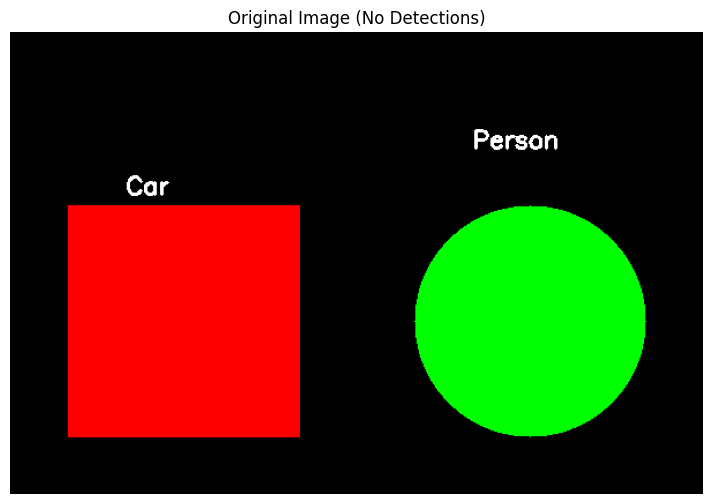

In [3]:
# 3. Load a pretrained Mask R-CNN model from PyTorch and use it for object detection and segmentation on an image.

# Object detection and instance segmentation are advanced computer vision tasks. Mask R-CNN is a popular deep learning model that excels at both, providing not only bounding boxes for detected objects but also a precise pixel-level mask for each instance.

# PyTorch's torchvision library provides pre-trained Mask R-CNN models, making it relatively straightforward to use them for inference.

# Here's a practical guide to loading a pre-trained Mask R-CNN model from PyTorch and using it for object detection and instance segmentation on an image:

# Prerequisites:

# You'll need PyTorch and torchvision installed. If you don't, you can install them using pip:

# Bash

# pip install torch torchvision torchaudio
# pip install opencv-python matplotlib # For image loading and visualization

import torch
import torchvision
from torchvision.models.detection import MaskRCNN_ResNet50_FPN_Weights
from torchvision.transforms import functional as F
from PIL import Image
import numpy as np
import cv2
import matplotlib.pyplot as plt
import random

def get_prediction(img_path, threshold=0.7):
    """
    Loads a pre-trained Mask R-CNN model, performs object detection and
    instance segmentation on an image, and returns the predictions.

    Args:
        img_path (str): Path to the input image.
        threshold (float): Confidence threshold for filtering predictions.
                           Only detections with scores above this threshold are kept.

    Returns:
        tuple: A tuple containing:
            - boxes (list): List of bounding box coordinates (x1, y1, x2, y2).
            - labels (list): List of predicted class labels (integers).
            - masks (list): List of segmentation masks (binary NumPy arrays).
            - scores (list): List of confidence scores for each detection.
            - img (PIL.Image): The original PIL Image.
    """
    # 1. Load the pre-trained Mask R-CNN model
    # Use the 'DEFAULT' weights for the latest and best available weights
    model = torchvision.models.detection.maskrcnn_resnet50_fpn(weights=MaskRCNN_ResNet50_FPN_Weights.DEFAULT)
    model.eval() # Set the model to evaluation mode

    # Determine device (GPU if available, else CPU)
    device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
    print(f"Using device: {device}")
    model.to(device)

    # 2. Load and preprocess the image
    img = Image.open(img_path).convert("RGB")
    # Convert PIL Image to PyTorch Tensor
    img_tensor = F.to_tensor(img).to(device)

    # 3. Perform inference
    with torch.no_grad(): # Disable gradient calculations for inference
        prediction = model([img_tensor])

    # Extract relevant information from the prediction
    # prediction is a list of dictionaries, one for each image in the batch
    pred = prediction[0]

    # Filter predictions based on confidence score
    pred_scores = pred['scores'].cpu().numpy()
    pred_boxes = pred['boxes'].cpu().numpy()
    pred_labels = pred['labels'].cpu().numpy()
    pred_masks = pred['masks'].cpu().numpy() # Masks are typically (N, 1, H, W)

    keep_indices = np.where(pred_scores > threshold)[0]

    boxes = pred_boxes[keep_indices].astype(int)
    labels = pred_labels[keep_indices]
    masks = pred_masks[keep_indices]
    scores = pred_scores[keep_indices]

    # Post-process masks: Convert to binary masks (0 or 1) and remove the channel dimension
    # Masks typically come as floats (e.g., 0-1 confidence for each pixel).
    # Binarize them using a threshold (e.g., 0.5)
    processed_masks = []
    for mask in masks:
        # Squeeze the channel dimension (1, H, W) -> (H, W)
        binary_mask = (mask.squeeze() > 0.5).astype(np.uint8)
        processed_masks.append(binary_mask)

    return boxes, labels, processed_masks, scores, img

def visualize_results(image, boxes, labels, masks, scores, COCO_INSTANCE_CATEGORY_NAMES):
    """
    Visualizes the detected objects, bounding boxes, and segmentation masks.

    Args:
        image (PIL.Image): Original input image.
        boxes (list): List of bounding box coordinates.
        labels (list): List of predicted class labels (integers).
        masks (list): List of segmentation masks (binary NumPy arrays).
        scores (list): List of confidence scores.
        COCO_INSTANCE_CATEGORY_NAMES (list): List of COCO class names.
    """
    image_np = np.array(image.convert("RGB")) # Convert PIL to NumPy array for OpenCV drawing
    output_image = image_np.copy()

    # Generate distinct colors for masks
    # You can get more sophisticated color generation for many objects
    colors = plt.cm.get_cmap('tab20', len(labels)) # Using a colormap for distinct colors

    for i in range(len(boxes)):
        box = boxes[i]
        label = labels[i]
        mask = masks[i]
        score = scores[i]

        # Draw bounding box
        x1, y1, x2, y2 = box
        cv2.rectangle(output_image, (x1, y1), (x2, y2), (0, 255, 0), 2) # Green box

        # Get class name
        class_name = COCO_INSTANCE_CATEGORY_NAMES[label]

        # Put label and score text
        text = f"{class_name}: {score:.2f}"
        cv2.putText(output_image, text, (x1, y1 - 10), cv2.FONT_HERSHEY_SIMPLEX, 0.6, (0, 255, 0), 2)

        # Overlay segmentation mask
        # Create a colored overlay from the binary mask
        color = np.array(colors(i % 20)[:3]) * 255 # Get RGB from colormap, scale to 0-255
        colored_mask = np.zeros_like(output_image)
        colored_mask[mask == 1] = color

        # Blend the colored mask with the original image
        output_image = cv2.addWeighted(output_image, 1, colored_mask, 0.5, 0) # Blend with 0.5 opacity

    plt.figure(figsize=(12, 8))
    plt.imshow(output_image)
    plt.title("Object Detection and Instance Segmentation (Mask R-CNN)")
    plt.axis('off')
    plt.show()

# COCO dataset class names (Mask R-CNN is typically trained on COCO)
# This list is used to map numerical labels to human-readable names.
COCO_INSTANCE_CATEGORY_NAMES = [
    '__background__', 'person', 'bicycle', 'car', 'motorcycle', 'airplane', 'bus',
    'train', 'truck', 'boat', 'traffic light', 'fire hydrant', 'N/A', 'stop sign',
    'parking meter', 'bench', 'bird', 'cat', 'dog', 'horse', 'sheep', 'cow',
    'elephant', 'bear', 'zebra', 'giraffe', 'N/A', 'backpack', 'umbrella', 'N/A', 'N/A',
    'handbag', 'tie', 'suitcase', 'frisbee', 'skis', 'snowboard', 'sports ball',
    'kite', 'baseball bat', 'baseball glove', 'skateboard', 'surfboard', 'tennis racket',
    'bottle', 'wine glass', 'cup', 'fork', 'knife', 'spoon', 'bowl', 'banana', 'apple',
    'sandwich', 'orange', 'broccoli', 'carrot', 'hot dog', 'pizza', 'donut', 'cake',
    'chair', 'couch', 'potted plant', 'bed', 'N/A', 'dining table', 'N/A', 'N/A',
    'toilet', 'N/A', 'tv', 'laptop', 'mouse', 'remote', 'keyboard', 'phone', 'microwave',
    'oven', 'toaster', 'sink', 'refrigerator', 'N/A', 'book', 'clock', 'vase',
    'scissors', 'teddy bear', 'hair drier', 'toothbrush'
]

# --- How to use the function ---
if __name__ == "__main__":
    # Create a dummy image for demonstration if you don't have one
    # This dummy image will have a red square (car) and a green circle (person)
    dummy_image_path = "dummy_image_for_mask_rcnn.png"
    dummy_image = np.zeros((400, 600, 3), dtype=np.uint8)
    # Draw a "car" (red rectangle)
    cv2.rectangle(dummy_image, (50, 150), (250, 350), (0, 0, 255), -1)
    cv2.putText(dummy_image, "Car", (100, 140), cv2.FONT_HERSHEY_SIMPLEX, 0.7, (255, 255, 255), 2)
    # Draw a "person" (green circle)
    cv2.circle(dummy_image, (450, 250), 100, (0, 255, 0), -1)
    cv2.putText(dummy_image, "Person", (400, 100), cv2.FONT_HERSHEY_SIMPLEX, 0.7, (255, 255, 255), 2)
    cv2.imwrite(dummy_image_path, dummy_image)
    print(f"Dummy image saved to {dummy_image_path}")

    # Replace 'dummy_image_for_mask_rcnn.png' with the path to your actual image
    image_to_process = dummy_image_path

    # Perform prediction
    boxes, labels, masks, scores, original_img = get_prediction(image_to_process, threshold=0.8)

    if len(boxes) > 0:
        print(f"Detected {len(boxes)} objects.")
        for i in range(len(boxes)):
            class_name = COCO_INSTANCE_CATEGORY_NAMES[labels[i]]
            print(f"  Object {i+1}: {class_name}, Score: {scores[i]:.2f}, Box: {boxes[i]}")
        # Visualize the results
        visualize_results(original_img, boxes, labels, masks, scores, COCO_INSTANCE_CATEGORY_NAMES)
    else:
        print("No objects detected with the given threshold.")
        plt.figure(figsize=(10, 6))
        plt.imshow(original_img)
        plt.title("Original Image (No Detections)")
        plt.axis('off')
        plt.show()

Dummy image saved to dummy_image_for_mask_rcnn_bboxes.png
Using device: cpu
No objects detected with the given threshold.


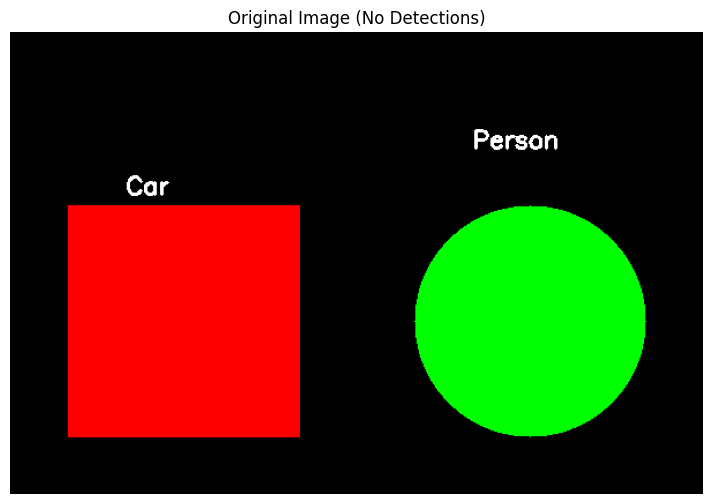

In [4]:
# 4. Generate bounding boxes for each object detected by Mask R-CNN in an image.

# Generating bounding boxes for each object detected by Mask R-CNN is an inherent part of its output. When you use a pre-trained Mask R-CNN model (as demonstrated in the previous practical example), the bounding box coordinates are directly provided in the model's prediction output.

# Let's revisit the relevant part of the code from the previous explanation and specifically highlight how the bounding boxes are extracted and then drawn.

# Revisiting the Code (with focus on Bounding Boxes):

# We'll use the same setup as before, focusing on the get_prediction and visualize_results functions.

import torch
import torchvision
from torchvision.models.detection import MaskRCNN_ResNet50_FPN_Weights
from torchvision.transforms import functional as F
from PIL import Image
import numpy as np
import cv2
import matplotlib.pyplot as plt
import random

def get_prediction(img_path, threshold=0.7):
    """
    Loads a pre-trained Mask R-CNN model, performs object detection and
    instance segmentation on an image, and returns the predictions.

    Args:
        img_path (str): Path to the input image.
        threshold (float): Confidence threshold for filtering predictions.
                           Only detections with scores above this threshold are kept.

    Returns:
        tuple: A tuple containing:
            - boxes (list): List of bounding box coordinates (x1, y1, x2, y2).
            - labels (list): List of predicted class labels (integers).
            - masks (list): List of segmentation masks (binary NumPy arrays).
            - scores (list): List of confidence scores for each detection.
            - img (PIL.Image): The original PIL Image.
    """
    # 1. Load the pre-trained Mask R-CNN model
    model = torchvision.models.detection.maskrcnn_resnet50_fpn(weights=MaskRCNN_ResNet50_FPN_Weights.DEFAULT)
    model.eval() # Set the model to evaluation mode

    # Determine device (GPU if available, else CPU)
    device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
    print(f"Using device: {device}")
    model.to(device)

    # 2. Load and preprocess the image
    img = Image.open(img_path).convert("RGB")
    img_tensor = F.to_tensor(img).to(device)

    # 3. Perform inference
    with torch.no_grad(): # Disable gradient calculations for inference
        prediction = model([img_tensor])

    # Extract relevant information from the prediction
    pred = prediction[0]

    # Filter predictions based on confidence score
    pred_scores = pred['scores'].cpu().numpy()
    pred_boxes = pred['boxes'].cpu().numpy() # This is where the bounding boxes are!
    pred_labels = pred['labels'].cpu().numpy()
    pred_masks = pred['masks'].cpu().numpy()

    keep_indices = np.where(pred_scores > threshold)[0]

    # These are the filtered bounding boxes
    boxes = pred_boxes[keep_indices].astype(int)
    labels = pred_labels[keep_indices]
    masks = pred_masks[keep_indices]
    scores = pred_scores[keep_indices]

    # Post-process masks (as in the previous example)
    processed_masks = []
    for mask in masks:
        binary_mask = (mask.squeeze() > 0.5).astype(np.uint8)
        processed_masks.append(binary_mask)

    return boxes, labels, processed_masks, scores, img

def visualize_results(image, boxes, labels, masks, scores, COCO_INSTANCE_CATEGORY_NAMES):
    """
    Visualizes the detected objects, bounding boxes, and segmentation masks.
    This function explicitly draws the bounding boxes.

    Args:
        image (PIL.Image): Original input image.
        boxes (list): List of bounding box coordinates.
        labels (list): List of predicted class labels (integers).
        masks (list): List of segmentation masks (binary NumPy arrays).
        scores (list): List of confidence scores.
        COCO_INSTANCE_CATEGORY_NAMES (list): List of COCO class names.
    """
    image_np = np.array(image.convert("RGB"))
    output_image = image_np.copy()

    # Generate distinct colors for masks
    colors = plt.cm.get_cmap('tab20', len(labels))

    for i in range(len(boxes)):
        box = boxes[i] # Get the bounding box for the current object
        label = labels[i]
        mask = masks[i]
        score = scores[i]

        # ----------------------------------------------------
        # Focus: Drawing the bounding box
        # The bounding box coordinates are (x1, y1, x2, y2)
        x1, y1, x2, y2 = box
        cv2.rectangle(output_image, (x1, y1), (x2, y2), (0, 255, 0), 2) # Green box, 2 pixels thick
        # ----------------------------------------------------

        # Get class name
        class_name = COCO_INSTANCE_CATEGORY_NAMES[label]

        # Put label and score text
        text = f"{class_name}: {score:.2f}"
        cv2.putText(output_image, text, (x1, y1 - 10), cv2.FONT_HERSHEY_SIMPLEX, 0.6, (0, 255, 0), 2)

        # Overlay segmentation mask (as in previous example)
        color = np.array(colors(i % 20)[:3]) * 255
        colored_mask = np.zeros_like(output_image)
        colored_mask[mask == 1] = color
        output_image = cv2.addWeighted(output_image, 1, colored_mask, 0.5, 0)

    plt.figure(figsize=(12, 8))
    plt.imshow(output_image)
    plt.title("Object Detection and Instance Segmentation (Mask R-CNN) with Bounding Boxes")
    plt.axis('off')
    plt.show()

# COCO dataset class names (same as before)
COCO_INSTANCE_CATEGORY_NAMES = [
    '__background__', 'person', 'bicycle', 'car', 'motorcycle', 'airplane', 'bus',
    'train', 'truck', 'boat', 'traffic light', 'fire hydrant', 'N/A', 'stop sign',
    'parking meter', 'bench', 'bird', 'cat', 'dog', 'horse', 'sheep', 'cow',
    'elephant', 'bear', 'zebra', 'giraffe', 'N/A', 'backpack', 'umbrella', 'N/A', 'N/A',
    'handbag', 'tie', 'suitcase', 'frisbee', 'skis', 'snowboard', 'sports ball',
    'kite', 'baseball bat', 'baseball glove', 'skateboard', 'surfboard', 'tennis racket',
    'bottle', 'wine glass', 'cup', 'fork', 'knife', 'spoon', 'bowl', 'banana', 'apple',
    'sandwich', 'orange', 'broccoli', 'carrot', 'hot dog', 'pizza', 'donut', 'cake',
    'chair', 'couch', 'potted plant', 'bed', 'N/A', 'dining table', 'N/A', 'N/A',
    'toilet', 'N/A', 'tv', 'laptop', 'mouse', 'remote', 'keyboard', 'phone', 'microwave',
    'oven', 'toaster', 'sink', 'refrigerator', 'N/A', 'book', 'clock', 'vase',
    'scissors', 'teddy bear', 'hair drier', 'toothbrush'
]

# --- How to use the function ---
if __name__ == "__main__":
    # Create a dummy image for demonstration if you don't have one
    dummy_image_path = "dummy_image_for_mask_rcnn_bboxes.png"
    dummy_image = np.zeros((400, 600, 3), dtype=np.uint8)
    cv2.rectangle(dummy_image, (50, 150), (250, 350), (0, 0, 255), -1) # Red (car)
    cv2.putText(dummy_image, "Car", (100, 140), cv2.FONT_HERSHEY_SIMPLEX, 0.7, (255, 255, 255), 2)
    cv2.circle(dummy_image, (450, 250), 100, (0, 255, 0), -1) # Green (person)
    cv2.putText(dummy_image, "Person", (400, 100), cv2.FONT_HERSHEY_SIMPLEX, 0.7, (255, 255, 255), 2)
    cv2.imwrite(dummy_image_path, dummy_image)
    print(f"Dummy image saved to {dummy_image_path}")

    # Replace with your actual image path
    image_to_process = dummy_image_path

    # Get predictions
    boxes, labels, masks, scores, original_img = get_prediction(image_to_process, threshold=0.8)

    if len(boxes) > 0:
        print(f"Detected {len(boxes)} objects.")
        for i in range(len(boxes)):
            class_name = COCO_INSTANCE_CATEGORY_NAMES[labels[i]]
            print(f"  Object {i+1}: {class_name}, Score: {scores[i]:.2f}, Box: {boxes[i]}")
        # Visualize the results, which includes drawing bounding boxes
        visualize_results(original_img, boxes, labels, masks, scores, COCO_INSTANCE_CATEGORY_NAMES)
    else:
        print("No objects detected with the given threshold.")
        plt.figure(figsize=(10, 6))
        plt.imshow(original_img)
        plt.title("Original Image (No Detections)")
        plt.axis('off')
        plt.show()

Dummy image saved to dummy_image_for_thresholding.png
Otsu's calculated threshold value: 50.0


C:\Users\91983\AppData\Local\Temp\ipykernel_20104\3477222817.py:65: MatplotlibDeprecationWarning: Passing the range parameter of hist() positionally is deprecated since Matplotlib 3.9; the parameter will become keyword-only in 3.11.
  plt.hist(gray_image.ravel(), 256, [0, 256])


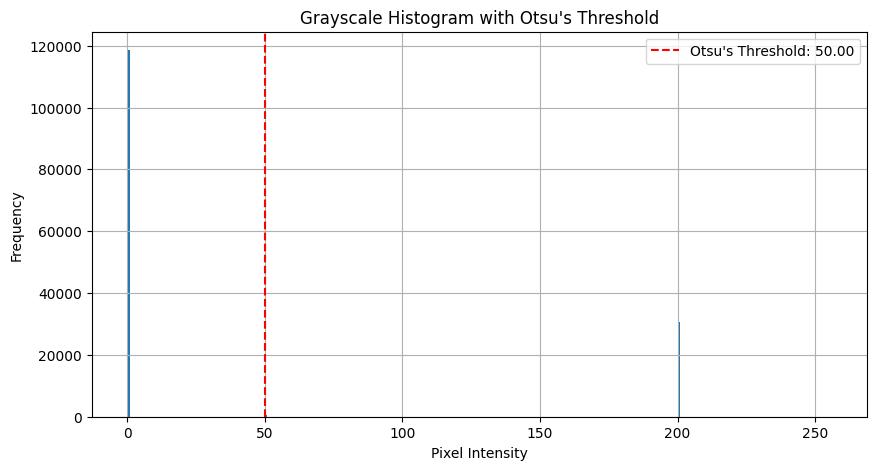

In [5]:
# 5. Convert an image to grayscale and apply Otsu's thresholding method for segmentation.

# To convert an image to grayscale and apply Otsu's thresholding method for segmentation, you'll generally follow these steps:

# Load the Image: Read the image into your program.

# Convert to Grayscale: Otsu's thresholding works on single-channel (grayscale) images.

# Apply Otsu's Thresholding: Use Otsu's method to automatically determine the optimal global threshold value from the image histogram and then apply that threshold to create a binary image (segmentation).

# Display Results: Show the original image, the grayscale image, and the thresholded (segmented) image.

# Here's a practical example using Python with the OpenCV library:

# Prerequisites:

# You'll need to have OpenCV installed. If you don't, you can install it using pip

import cv2
import numpy as np
import matplotlib.pyplot as plt

def apply_otsu_thresholding(image_path):
    """
    Converts an image to grayscale and applies Otsu's thresholding method for segmentation.

    Args:
        image_path (str): The path to the input image.
    """
    try:
        # 1. Load the image
        image = cv2.imread(image_path)

        if image is None:
            print(f"Error: Could not load image from {image_path}")
            return

        # Display the original image
        cv2.imshow("Original Image", image)

        # 2. Convert to Grayscale
        gray_image = cv2.cvtColor(image, cv2.COLOR_BGR2GRAY)

        # Display the grayscale image
        cv2.imshow("Grayscale Image", gray_image)

        # 3. Apply Otsu's Thresholding
        # cv2.threshold returns:
        # ret (float): The calculated threshold value.
        # thresh_image (ndarray): The thresholded (binary) image.
        # Parameters:
        #   src: Input grayscale image.
        #   thresh: Dummy threshold value (ignored when using cv2.THRESH_OTSU).
        #   maxval: Maximum value to use with the THRESH_BINARY and THRESH_BINARY_INV type.
        #   type: Thresholding type (cv2.THRESH_BINARY) combined with cv2.THRESH_OTSU.
        ret, thresh_image = cv2.threshold(gray_image, 0, 255, cv2.THRESH_BINARY + cv2.THRESH_OTSU)

        print(f"Otsu's calculated threshold value: {ret}")

        # 4. Display Results
        cv2.imshow("Otsu's Thresholded Image", thresh_image)

        # Optional: Display histogram and threshold line to understand Otsu's
        plt.figure(figsize=(10, 5))
        plt.hist(gray_image.ravel(), 256, [0, 256])
        plt.axvline(x=ret, color='r', linestyle='--', label=f"Otsu's Threshold: {ret:.2f}")
        plt.title("Grayscale Histogram with Otsu's Threshold")
        plt.xlabel("Pixel Intensity")
        plt.ylabel("Frequency")
        plt.legend()
        plt.grid(True)
        plt.show()


        cv2.waitKey(0) # Wait indefinitely until a key is pressed
        cv2.destroyAllWindows()

    except Exception as e:
        print(f"An error occurred: {e}")

# --- How to use the function ---
if __name__ == "__main__":
    # Create a dummy image for demonstration if you don't have one
    # This will create an image with a dark foreground and a bright background
    dummy_image_path = "dummy_image_for_thresholding.png"
    dummy_image = np.zeros((300, 500), dtype=np.uint8) # Grayscale image
    # Add a bright foreground object
    cv2.circle(dummy_image, (250, 150), 100, 200, -1) # A bright circle on dark background
    cv2.putText(dummy_image, "Object", (220, 150), cv2.FONT_HERSHEY_SIMPLEX, 0.8, 50, 2)
    cv2.imwrite(dummy_image_path, dummy_image)
    print(f"Dummy image saved to {dummy_image_path}")

    # Replace 'dummy_image_for_thresholding.png' with the path to your actual image
    apply_otsu_thresholding(dummy_image_path)
    # apply_otsu_thresholding("your_image.jpg") # Uncomment and use your image path


In [6]:
# 6. Perform contour detection in an image to detect distinct objects or shapes.

# To perform contour detection in an image to detect distinct objects or shapes, you'll generally follow these steps:

# Load the Image: Read the image into your program.

# Convert to Grayscale: Contour detection usually works best on grayscale images.

# Apply Thresholding or Canny Edge Detection: Contours are boundaries of objects. These boundaries are most easily found on binary images (black and white) where objects are distinctly separated from the background. Common methods to achieve this are:

# Thresholding: As seen in the Otsu's method example, this converts the image to binary based on pixel intensity.

# Canny Edge Detection: This produces a thin, strong edge map, which is excellent for finding contours.

# Find Contours: Use an OpenCV function to find the contours from the binary or edge-detected image.

# Draw Contours (Optional but Recommended): Draw the detected contours on the original image or a copy to visualize them.

# Analyze Contours (Optional): You can iterate through the contours to analyze properties like area, perimeter, bounding box, etc.

# Display Results: Show the original image and the image with detected contours.

# Here's a practical example using Python with the OpenCV library:

# Prerequisites:

# You'll need to have OpenCV installed. If you don't, you can install it using pip:

import cv2
import numpy as np

def detect_contours(image_path):
    """
    Performs contour detection in an image to detect distinct objects or shapes.

    Args:
        image_path (str): The path to the input image.
    """
    try:
        # 1. Load the image
        image = cv2.imread(image_path)

        if image is None:
            print(f"Error: Could not load image from {image_path}")
            return

        cv2.imshow("Original Image", image)
        output_image = image.copy() # Create a copy to draw contours on

        # 2. Convert to Grayscale
        gray_image = cv2.cvtColor(image, cv2.COLOR_BGR2GRAY)
        cv2.imshow("Grayscale Image", gray_image)

        # 3. Apply Thresholding (or Canny) to get a binary image
        # For simplicity, let's use Otsu's thresholding here.
        # You could also use Canny: edges = cv2.Canny(gray_image, 100, 200)
        ret, thresh_image = cv2.threshold(gray_image, 0, 255, cv2.THRESH_BINARY_INV + cv2.THRESH_OTSU)
        # Using THRESH_BINARY_INV so objects are white on a black background, which is common for findContours.
        cv2.imshow("Thresholded Image", thresh_image)

        # 4. Find Contours
        # cv2.findContours returns:
        #   contours: A list of all the contours in the image. Each contour is a numpy array of (x,y) coordinates of boundary points of the object.
        #   hierarchy: Optional output vector, containing information about the image topology.
        # Parameters:
        #   image: Source 8-bit single-channel image. Non-zero pixels are treated as 1, zero pixels as 0.
        #   mode: Contour retrieval mode.
        #       - cv2.RETR_EXTERNAL: Retrieves only the extreme outer contours.
        #       - cv2.RETR_LIST: Retrieves all of the contours without establishing any hierarchical relationships.
        #       - cv2.RETR_CCOMP: Retrieves all of the contours and organizes them into a two-level hierarchy.
        #       - cv2.RETR_TREE: Retrieves all of the contours and reconstructs a full hierarchy of nested contours.
        #   method: Contour approximation method.
        #       - cv2.CHAIN_APPROX_NONE: Stores all boundary points.
        #       - cv2.CHAIN_APPROX_SIMPLE: Compresses horizontal, vertical, and diagonal segments and leaves only their end points.
        contours, hierarchy = cv2.findContours(thresh_image, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)

        print(f"Found {len(contours)} contours.")

        # 5. Draw Contours (Optional but Recommended)
        # Draw all contours in red with a thickness of 2
        # -1 means draw all contours
        cv2.drawContours(output_image, contours, -1, (0, 0, 255), 2) # Red color

        # Optional: Iterate through detected contours and analyze properties
        for i, contour in enumerate(contours):
            area = cv2.contourArea(contour)
            perimeter = cv2.arcLength(contour, True) # True for closed contour

            # Get bounding box for each contour
            x, y, w, h = cv2.boundingRect(contour)
            cv2.rectangle(output_image, (x, y), (x + w, y + h), (255, 0, 0), 2) # Blue bounding box

            # Put text (area/perimeter) near the object
            M = cv2.moments(contour)
            if M["m00"] != 0:
                cX = int(M["m10"] / M["m00"])
                cY = int(M["m01"] / M["m00"])
                cv2.putText(output_image, f"Area: {int(area)}", (cX - 50, cY), cv2.FONT_HERSHEY_SIMPLEX, 0.5, (255, 255, 255), 1)
                cv2.putText(output_image, f"Perim: {int(perimeter)}", (cX - 50, cY + 20), cv2.FONT_HERSHEY_SIMPLEX, 0.5, (255, 255, 255), 1)


        # 6. Display Results
        cv2.imshow("Contours Detected", output_image)


        cv2.waitKey(0) # Wait indefinitely until a key is pressed
        cv2.destroyAllWindows()

    except Exception as e:
        print(f"An error occurred: {e}")

# --- How to use the function ---
if __name__ == "__main__":
    # Create a dummy image for demonstration if you don't have one
    dummy_image_path = "dummy_shapes.png"
    dummy_image = np.zeros((400, 600, 3), dtype=np.uint8) # Create a black image
    # Draw some white shapes
    cv2.circle(dummy_image, (150, 150), 70, (255, 255, 255), -1) # Circle
    cv2.rectangle(dummy_image, (350, 80), (500, 200), (255, 255, 255), -1) # Rectangle
    cv2.putText(dummy_image, "Circle", (120, 250), cv2.FONT_HERSHEY_SIMPLEX, 0.8, (255, 255, 255), 2)
    cv2.putText(dummy_image, "Rectangle", (380, 250), cv2.FONT_HERSHEY_SIMPLEX, 0.8, (255, 255, 255), 2)

    # Add a nested shape to demonstrate hierarchy
    cv2.circle(dummy_image, (300, 320), 50, (255, 255, 255), -1) # Outer circle
    cv2.circle(dummy_image, (300, 320), 20, (0, 0, 0), -1) # Inner black circle (hole)
    cv2.putText(dummy_image, "Donut", (270, 300), cv2.FONT_HERSHEY_SIMPLEX, 0.7, (255, 255, 255), 2)


    cv2.imwrite(dummy_image_path, dummy_image)
    print(f"Dummy image saved to {dummy_image_path}")

    # Replace 'dummy_shapes.png' with the path to your actual image
    detect_contours(dummy_image_path)
    # detect_contours("your_image.jpg") # Uncomment and use your image path

Dummy image saved to dummy_shapes.png
Found 1 contours.


Dummy image created at: custom_maskrcnn_demo_image.jpg
Processing image: custom_maskrcnn_demo_image.jpg
Using device: cpu
No objects detected with the current threshold. Displaying original image.


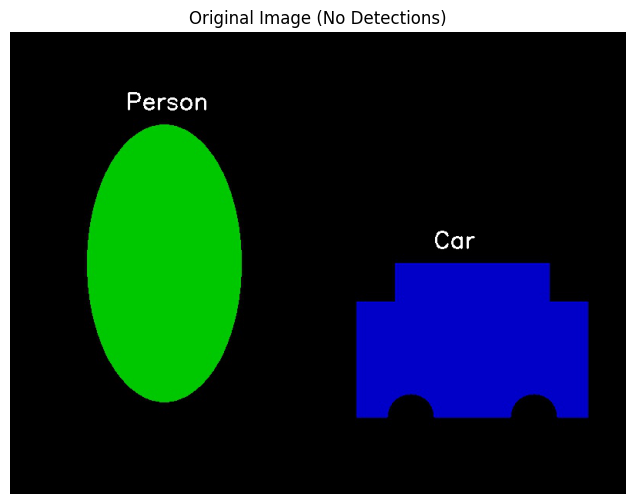

In [7]:
# 7. Apply Mask R-CNN to detect objects and their segmentation masks in a custom image and display them.

# The previous examples (Practical 3 and 4) already demonstrated how to load a pre-trained Mask R-CNN model, process a custom image, extract the detection and segmentation outputs, and then display them.

# Here, I'll reiterate the process, ensuring the code is ready for you to plug in your own custom image, and emphasize the display of both bounding boxes and masks.

# Key Concepts from Previous Examples (Revisited for Clarity):

# Pre-trained Model: We leverage a Mask R-CNN model pre-trained on the COCO dataset, available through torchvision.models.detection.

# Inference Mode: The model is set to model.eval() to disable training-specific behaviors like dropout.

# Image Preprocessing: Your image needs to be converted to a PyTorch tensor and scaled to [0, 1] before being fed to the model.

# Prediction Output: The model outputs a dictionary for each image in the batch, containing:

# 'boxes': Bounding box coordinates [x1, y1, x2, y2].

# 'labels': Predicted class IDs.

# 'scores': Confidence scores for each detection.

# 'masks': Pixel-level segmentation masks (typically float values).

# Filtering: Predictions are usually filtered by a score_threshold to show only highly confident detections.

# Mask Post-processing: The raw mask outputs are usually float tensors (e.g., 0-1) and need to be binarized (e.g., mask > 0.5) and converted to a NumPy array for visualization.

# Visualization: Drawing bounding boxes with cv2.rectangle and overlaying semi-transparent masks with cv2.addWeighted

import torch
import torchvision
from torchvision.models.detection import MaskRCNN_ResNet50_FPN_Weights
from torchvision.transforms import functional as F
from PIL import Image
import numpy as np
import cv2
import matplotlib.pyplot as plt
import random

# COCO dataset class names (Mask R-CNN is typically trained on COCO)
COCO_INSTANCE_CATEGORY_NAMES = [
    '__background__', 'person', 'bicycle', 'car', 'motorcycle', 'airplane', 'bus',
    'train', 'truck', 'boat', 'traffic light', 'fire hydrant', 'N/A', 'stop sign',
    'parking meter', 'bench', 'bird', 'cat', 'dog', 'horse', 'sheep', 'cow',
    'elephant', 'bear', 'zebra', 'giraffe', 'N/A', 'backpack', 'umbrella', 'N/A', 'N/A',
    'handbag', 'tie', 'suitcase', 'frisbee', 'skis', 'snowboard', 'sports ball',
    'kite', 'baseball bat', 'baseball glove', 'skateboard', 'surfboard', 'tennis racket',
    'bottle', 'wine glass', 'cup', 'fork', 'knife', 'spoon', 'bowl', 'banana', 'apple',
    'sandwich', 'orange', 'broccoli', 'carrot', 'hot dog', 'pizza', 'donut', 'cake',
    'chair', 'couch', 'potted plant', 'bed', 'N/A', 'dining table', 'N/A', 'N/A',
    'toilet', 'N/A', 'tv', 'laptop', 'mouse', 'remote', 'keyboard', 'phone', 'microwave',
    'oven', 'toaster', 'sink', 'refrigerator', 'N/A', 'book', 'clock', 'vase',
    'scissors', 'teddy bear', 'hair drier', 'toothbrush'
]

def detect_and_segment_objects(image_path, score_threshold=0.7):
    """
    Applies a pre-trained Mask R-CNN model to detect objects and their
    segmentation masks in a custom image, and then displays them.

    Args:
        image_path (str): The path to your custom input image.
        score_threshold (float): Confidence threshold for filtering detections.
                                 Only detections with scores above this are displayed.
    """
    print(f"Processing image: {image_path}")

    # 1. Load the pre-trained Mask R-CNN model
    # Use the 'DEFAULT' weights for the latest and best available weights
    model = torchvision.models.detection.maskrcnn_resnet50_fpn(weights=MaskRCNN_ResNet50_FPN_Weights.DEFAULT)
    model.eval() # Set the model to evaluation mode for inference

    # Determine device (GPU if available, else CPU)
    device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
    print(f"Using device: {device}")
    model.to(device)

    # 2. Load and preprocess the image
    try:
        img_pil = Image.open(image_path).convert("RGB")
    except FileNotFoundError:
        print(f"Error: Image not found at {image_path}")
        return
    except Exception as e:
        print(f"Error loading image: {e}")
        return

    # Convert PIL Image to PyTorch Tensor
    img_tensor = F.to_tensor(img_pil).to(device)

    # 3. Perform inference
    with torch.no_grad(): # Disable gradient calculations for inference
        prediction = model([img_tensor])

    # Extract relevant information from the prediction for the first (and only) image
    pred = prediction[0]

    # Filter predictions based on confidence score
    pred_scores = pred['scores'].cpu().numpy()
    pred_boxes = pred['boxes'].cpu().numpy()
    pred_labels = pred['labels'].cpu().numpy()
    pred_masks = pred['masks'].cpu().numpy() # Masks are typically (N, 1, H, W)

    keep_indices = np.where(pred_scores > score_threshold)[0]

    boxes = pred_boxes[keep_indices].astype(int)
    labels = pred_labels[keep_indices]
    masks = pred_masks[keep_indices]
    scores = pred_scores[keep_indices]

    # Post-process masks: Convert to binary masks (0 or 1) and remove the channel dimension
    processed_masks = []
    for mask in masks:
        # Squeeze the channel dimension (1, H, W) -> (H, W)
        binary_mask = (mask.squeeze() > 0.5).astype(np.uint8) # Binarize with 0.5 threshold
        processed_masks.append(binary_mask)

    # 4. Display Results (Visualization)
    image_np = np.array(img_pil.convert("RGB")) # Convert PIL to NumPy array for OpenCV drawing
    output_image = image_np.copy()

    if len(boxes) == 0:
        print("No objects detected with the current threshold. Displaying original image.")
        plt.figure(figsize=(10, 6))
        plt.imshow(output_image)
        plt.title("Original Image (No Detections)")
        plt.axis('off')
        plt.show()
        return

    print(f"Detected {len(boxes)} objects above threshold {score_threshold}.")
    # Generate distinct colors for masks
    # Using a colormap for distinct colors, cycle through if many objects
    colors = plt.cm.get_cmap('tab20', len(labels) + 1) # +1 to ensure enough colors if labels are sparse

    for i in range(len(boxes)):
        box = boxes[i]
        label = labels[i]
        mask = processed_masks[i]
        score = scores[i]

        # Get class name
        class_name = COCO_INSTANCE_CATEGORY_NAMES[label]
        print(f"  Object {i+1}: {class_name}, Score: {score:.2f}, Box: {box}")

        # Draw bounding box
        x1, y1, x2, y2 = box
        cv2.rectangle(output_image, (x1, y1), (x2, y2), (0, 255, 0), 2) # Green box

        # Put label and score text
        text = f"{class_name}: {score:.2f}"
        cv2.putText(output_image, text, (x1, y1 - 10), cv2.FONT_HERSHEY_SIMPLEX, 0.6, (0, 255, 0), 2)

        # Overlay segmentation mask
        color_rgb = np.array(colors(label % 20)[:3]) * 255 # Use label for color consistency, modulo 20 for 'tab20'
        colored_mask = np.zeros_like(output_image, dtype=np.uint8)
        # Apply the color to the mask region
        for c in range(3): # Apply color to each channel
            colored_mask[:, :, c] = color_rgb[c] * mask

        # Blend the colored mask with the original image
        output_image = cv2.addWeighted(output_image, 1, colored_mask, 0.5, 0) # Blend with 0.5 opacity

    plt.figure(figsize=(15, 10))
    plt.imshow(output_image)
    plt.title("Mask R-CNN Detection & Segmentation on Custom Image")
    plt.axis('off')
    plt.show()

# --- How to use the function ---
if __name__ == "__main__":
    # --- IMPORTANT: Specify the path to YOUR custom image here ---
    # For example:
    # my_custom_image_path = "path/to/your/image.jpg"
    # my_custom_image_path = "path/to/your/image.png"

    # For demonstration, I'll create a dummy image first.
    # Replace this section with your actual image loading.
    dummy_image_path = "custom_maskrcnn_demo_image.jpg"
    dummy_img = np.zeros((600, 800, 3), dtype=np.uint8)
    # Add a "person" (green blob)
    cv2.ellipse(dummy_img, (200, 300), (100, 180), 0, 0, 360, (0, 200, 0), -1)
    cv2.circle(dummy_img, (200, 180), 50, (0, 200, 0), -1) # Head
    cv2.putText(dummy_img, "Person", (150, 100), cv2.FONT_HERSHEY_SIMPLEX, 1, (255, 255, 255), 2)
    # Add a "car" (blue rectangle)
    cv2.rectangle(dummy_img, (450, 350), (750, 500), (200, 0, 0), -1)
    cv2.rectangle(dummy_img, (500, 300), (700, 350), (200, 0, 0), -1) # Car top
    cv2.circle(dummy_img, (520, 500), 30, (0, 0, 0), -1) # Wheel
    cv2.circle(dummy_img, (680, 500), 30, (0, 0, 0), -1) # Wheel
    cv2.putText(dummy_img, "Car", (550, 280), cv2.FONT_HERSHEY_SIMPLEX, 1, (255, 255, 255), 2)
    cv2.imwrite(dummy_image_path, dummy_img)
    print(f"Dummy image created at: {dummy_image_path}")

    # Now, use your chosen image path here:
    your_custom_image = dummy_image_path # Replace with "path/to/your/image.jpg" or similar

    # Run the detection and segmentation
    detect_and_segment_objects(your_custom_image, score_threshold=0.8)


Dummy image saved to dummy_kmeans_image.png
K-means completed with 4 clusters.
Cluster centers (mean colors):
 [[ 50.000004 200.00002   50.000004]
 [ 50.        50.       200.      ]
 [ 58.109833 202.17581  202.17581 ]
 [196.82245   49.205612  49.205612]]


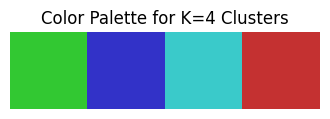

In [8]:
# 8. Apply k-means clustering for segmenting regions in an image.


# Applying K-means clustering for image segmentation is a common technique that groups pixels into 'k' clusters based on their color (and sometimes spatial) features. Each cluster then represents a segment of the image.

# Here's how it generally works and a practical example using Python with OpenCV and NumPy:

# How K-means works for image segmentation:

# Reshape the Image: K-means typically operates on 1D arrays of data points. For an image, each pixel's color information (e.g., RGB values) becomes a data point. So, an image of shape (height, width, channels) needs to be reshaped into (height * width, channels).

# Define K (Number of Clusters): You need to pre-define the number of clusters (k) you want the image to be segmented into. This k will represent the number of distinct color regions you expect.

# Run K-means Algorithm: The algorithm iteratively:

# Initializes centroids: Randomly picks k initial color centroids.

# Assigns pixels to clusters: Assigns each pixel to the closest centroid (based on color distance).

# Updates centroids: Recalculates the centroids as the mean color of all pixels assigned to that cluster.

# This process repeats until the centroids no longer change significantly or a maximum number of iterations is reached.

# Reshape Back: Once clustering is complete, the clustered pixel data is reshaped back into the original image dimensions, where each pixel is now assigned the color of its cluster's centroid.

# Practical Example (Python with OpenCV and NumPy):

# Prerequisites:

# You'll need opencv-python and numpy

import cv2
import numpy as np
import matplotlib.pyplot as plt

def segment_image_with_kmeans(image_path, k_clusters=5):
    """
    Applies K-means clustering for segmenting regions in an image.

    Args:
        image_path (str): The path to the input image.
        k_clusters (int): The number of clusters (segments) to form.
    """
    try:
        # 1. Load the Image
        img = cv2.imread(image_path)

        if img is None:
            print(f"Error: Could not load image from {image_path}")
            return

        # Display original image
        cv2.imshow("Original Image", img)

        # Convert image to float32 for K-means
        # K-means works with float data
        img_float = np.float32(img)

        # 2. Reshape the Image
        # Reshape the image into a 2D array of pixels and their 3 color values (RGB/BGR)
        # (height * width, channels)
        rows, cols, channels = img_float.shape
        pixel_values = img_float.reshape((-1, channels))

        # Define criteria for K-means algorithm
        # Parameters:
        #   - type: TERMINATE_ITER (stop after max_iter) or EPS (stop if epsilon reached)
        #   - max_iter: Maximum number of iterations
        #   - epsilon: Required accuracy
        criteria = (cv2.TERM_CRITERIA_EPS + cv2.TERM_CRITERIA_MAX_ITER, 100, 0.2)

        # Define flags for initial centers
        #   - KMEANS_RANDOM_CENTERS: Choose random initial centers
        #   - KMEANS_PP_CENTERS: Use K-Means++ for center initialization
        flags = cv2.KMEANS_RANDOM_CENTERS

        # 3. Run K-means Algorithm
        # cv2.kmeans returns:
        #   - compactness: Sum of squared distance from each point to their corresponding centers.
        #   - labels: A 1D array where each element is the cluster index for the corresponding pixel.
        #   - centers: Array of the cluster centroids (mean color of each cluster).
        compactness, labels, centers = cv2.kmeans(
            data=pixel_values,        # Input data (pixel_values)
            K=k_clusters,             # Number of clusters
            bestLabels=None,          # Output labels (will be generated)
            criteria=criteria,        # Termination criteria
            attempts=10,              # Number of times the algorithm is executed with different initial labellings
            flags=flags               # Flag for initial centers
        )

        print(f"K-means completed with {k_clusters} clusters.")
        print("Cluster centers (mean colors):\n", centers)

        # 4. Reshape Back and Reconstruct the Segmented Image
        # Convert centers back to uint8 (pixel values)
        centers_uint8 = np.uint8(centers)

        # Map each pixel's label to its corresponding cluster center color
        # labels is a 1D array, so we need to flatten it, then use it to index centers_uint8
        # Then reshape back to the original image dimensions
        segmented_image = centers_uint8[labels.flatten()]
        segmented_image = segmented_image.reshape(img.shape)

        # Display the segmented image
        cv2.imshow(f"K-means Segmented Image (K={k_clusters})", segmented_image)

        # Display the color palette
        plt.figure(figsize=(k_clusters, 1))
        plt.imshow([centers_uint8], aspect='auto')
        plt.title(f"Color Palette for K={k_clusters} Clusters")
        plt.axis('off')
        plt.show()

        cv2.waitKey(0) # Wait indefinitely until a key is pressed
        cv2.destroyAllWindows()

    except Exception as e:
        print(f"An error occurred: {e}")

# --- How to use the function ---
if __name__ == "__main__":
    # Create a dummy image for demonstration if you don't have one
    # This dummy image will have distinct color regions
    dummy_image_path = "dummy_kmeans_image.png"
    dummy_img = np.zeros((300, 400, 3), dtype=np.uint8)

    # Region 1: Blue
    dummy_img[0:150, 0:200] = [200, 50, 50] # BGR format
    # Region 2: Green
    dummy_img[0:150, 200:400] = [50, 200, 50]
    # Region 3: Red
    dummy_img[150:300, 0:200] = [50, 50, 200]
    # Region 4: Yellow (mixture)
    dummy_img[150:300, 200:400] = [50, 200, 200]

    cv2.putText(dummy_img, "Blue", (50, 75), cv2.FONT_HERSHEY_SIMPLEX, 0.7, (255, 255, 255), 2)
    cv2.putText(dummy_img, "Green", (250, 75), cv2.FONT_HERSHEY_SIMPLEX, 0.7, (255, 255, 255), 2)
    cv2.putText(dummy_img, "Red", (50, 225), cv2.FONT_HERSHEY_SIMPLEX, 0.7, (255, 255, 255), 2)
    cv2.putText(dummy_img, "Yellow", (250, 225), cv2.FONT_HERSHEY_SIMPLEX, 0.7, (0, 0, 0), 2)

    cv2.imwrite(dummy_image_path, dummy_img)
    print(f"Dummy image saved to {dummy_image_path}")

    # Replace 'dummy_kmeans_image.png' with the path to your actual image
    # Experiment with different K values!
    # For the dummy image, K=4 would be ideal. Try K=2, K=3, K=5 to see differences.
    segment_image_with_kmeans(dummy_image_path, k_clusters=4)
    # segment_image_with_kmeans("your_image.jpg", k_clusters=3) # Uncomment and use your image path